<a href="https://colab.research.google.com/github/essanchristian-maker/DI-Bootcamp/blob/master/Week3_day3_Mini_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Configuration**

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import requests
import io
from scipy import stats

def load_csv_from_zip_url(url):
    response = requests.get(url)
    z = zipfile.ZipFile(io.BytesIO(response.content))
    csv_name = [f for f in z.namelist() if f.endswith(".csv")][0]
    return pd.read_csv(z.open(csv_name))

url_aapl = "https://github.com/devtlv/Datasets-GEN-AI-Bootcamp/raw/refs/heads/main/Week%203/W3D4%20-%20Mini%20Project/Apple%20Stock%20Prices%20From%201981%20to%202023.zip"

aapl_df = load_csv_from_zip_url(url_aapl)

print(aapl_df.columns.tolist())
print(aapl_df.shape)
print(aapl_df.dtypes)
print("\nNull values :")
print(aapl_df.isnull().sum())
aapl_df.head()

['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
(10608, 7)
Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object

Null values :
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


,Date,Open,High,Low,Close,Adj Close,Volume
0,02/01/1981,0.154018,0.155134,0.154018,0.154018,0.119849,21660800
1,05/01/1981,0.151228,0.151228,0.150670,0.150670,0.117244,35728000
2,06/01/1981,0.144531,0.144531,0.143973,0.143973,0.112032,45158400
3,07/01/1981,0.138393,0.138393,0.137835,0.137835,0.107256,55686400
4,08/01/1981,0.135603,0.135603,0.135045,0.135045,0.105085,39827200


**Étape 2 — Convertir la date et vérifier les séries chronologiques**

In [7]:

aapl_df["Date"] = pd.to_datetime(aapl_df["Date"], format="%d/%m/%Y")
aapl_df = aapl_df.sort_values("Date").reset_index(drop=True)

print(f"Date range : {aapl_df['Date'].min()} → {aapl_df['Date'].max()}")
print(f"Total days : {len(aapl_df)}")
aapl_df.head()

Date range : 1981-01-02 00:00:00 → 2023-01-27 00:00:00
Total days : 10608


,Date,Open,High,Low,Close,Adj Close,Volume
0,1981-01-02,0.154018,0.155134,0.154018,0.154018,0.119849,21660800
1,1981-01-05,0.151228,0.151228,0.150670,0.150670,0.117244,35728000
2,1981-01-06,0.144531,0.144531,0.143973,0.143973,0.112032,45158400
3,1981-01-07,0.138393,0.138393,0.137835,0.137835,0.107256,55686400
4,1981-01-08,0.135603,0.135603,0.135045,0.135045,0.105085,39827200


**Étape 3 — Tracer les prix de clôture et le volume**


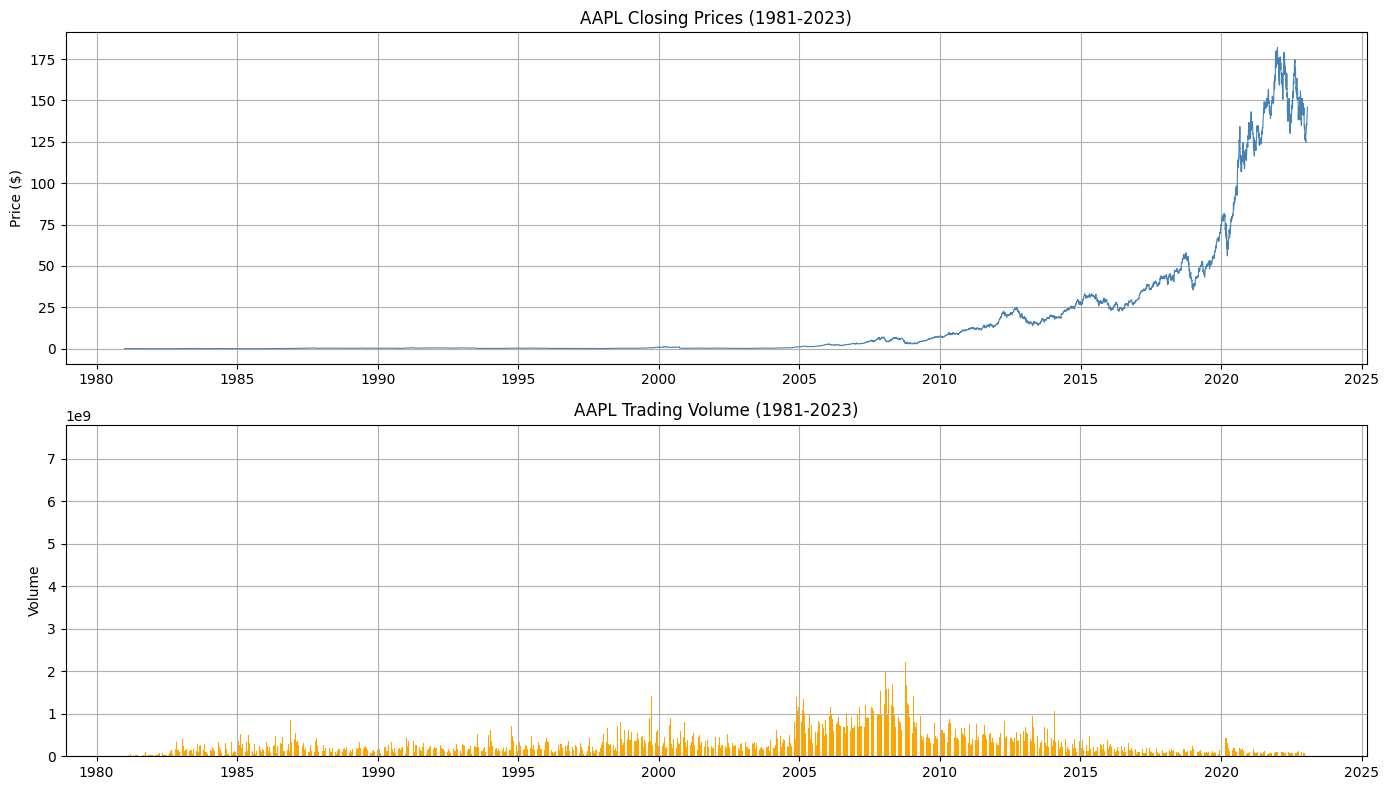

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Closing prices
axes[0].plot(aapl_df["Date"], aapl_df["Close"], color="steelblue", linewidth=0.8)
axes[0].set_title("AAPL Closing Prices (1981-2023)")
axes[0].set_ylabel("Price ($)")
axes[0].grid(True)

# Volume
axes[1].bar(aapl_df["Date"], aapl_df["Volume"], color="orange", width=1)
axes[1].set_title("AAPL Trading Volume (1981-2023)")
axes[1].set_ylabel("Volume")
axes[1].grid(True)

plt.tight_layout()
plt.show()

**Étape 4 — Graphique en chandeliers**


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 2.8 MB/s eta 0:00:00


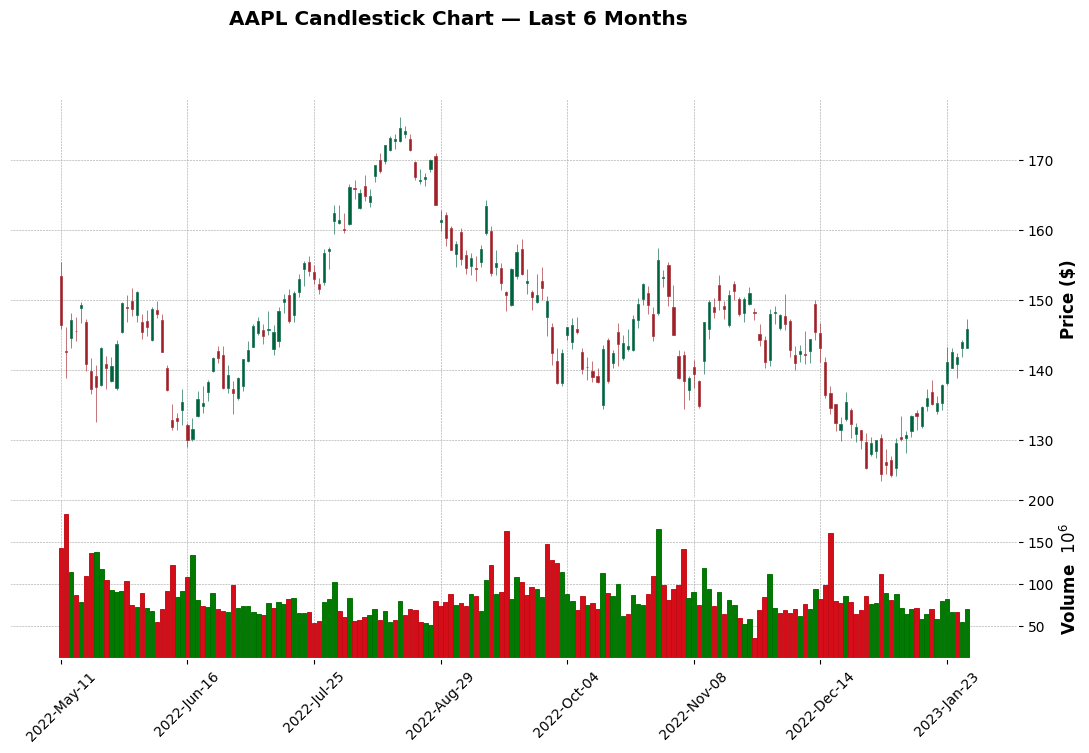

In [9]:
!pip install mplfinance

import mplfinance as mpf

# Set Date as index
aapl_candle = aapl_df.set_index("Date")

# Plot last 6 months for readability
mpf.plot(aapl_candle.tail(180),
         type="candle",
         style="charles",
         title="AAPL Candlestick Chart — Last 6 Months",
         ylabel="Price ($)",
         volume=True,
         figsize=(14, 8))

**Étape 5 — Statistiques récapitulatives + Moyenne mobile**

 SUMMARY STATISTICS 
            Open       High        Low      Close        Volume
count  10608.000  10608.000  10608.000  10608.000  1.060800e+04
mean      16.689     16.880     16.501     16.697  3.275098e+08
std       35.451     35.883     35.031     35.474  3.378203e+08
min        0.050      0.050      0.049      0.049  0.000000e+00
25%        0.288      0.297      0.282      0.289  1.213044e+08
50%        0.489      0.496      0.480      0.488  2.145976e+08
75%       16.321     16.418     16.151     16.270  4.066804e+08
max      182.630    182.940    179.120    182.010  7.421641e+09


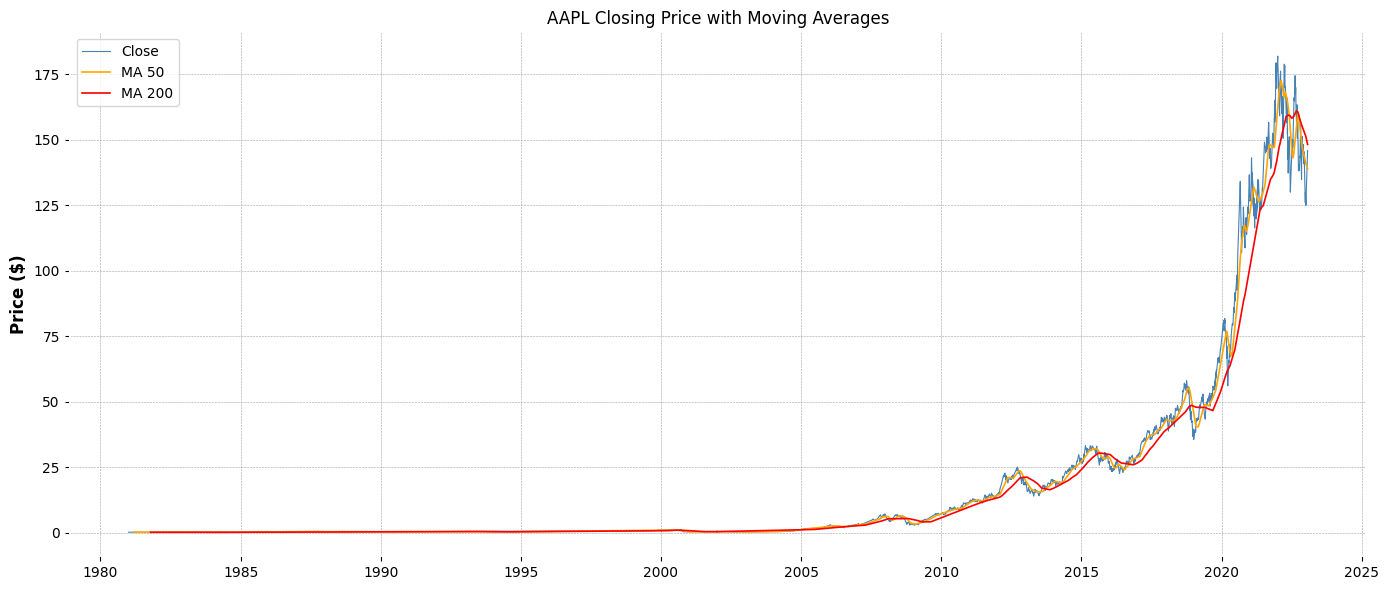

In [10]:
# Summary statistics
print(" SUMMARY STATISTICS ")
print(aapl_df[["Open", "High", "Low", "Close", "Volume"]].describe().round(3))

# Moving averages on Close
aapl_df["MA_50"]  = aapl_df["Close"].rolling(window=50).mean()
aapl_df["MA_200"] = aapl_df["Close"].rolling(window=200).mean()

# Plot
plt.figure(figsize=(14, 6))
plt.plot(aapl_df["Date"], aapl_df["Close"],  label="Close",   linewidth=0.8, color="steelblue")
plt.plot(aapl_df["Date"], aapl_df["MA_50"],  label="MA 50",   linewidth=1.2, color="orange")
plt.plot(aapl_df["Date"], aapl_df["MA_200"], label="MA 200",  linewidth=1.2, color="red")
plt.title("AAPL Closing Price with Moving Averages")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Étape 6 — Test T : Comparez les cours de clôture sur plusieurs années**


In [12]:
# Extract two years for comparison
year_2020 = aapl_df[aapl_df["Date"].dt.year == 2020]["Close"]
year_2022 = aapl_df[aapl_df["Date"].dt.year == 2022]["Close"]

t_stat, p_value = stats.ttest_ind(year_2020, year_2022)

print(" T-TEST : 2020 vs 2022 ")
print(f"Mean 2020  : {year_2020.mean():.2f}")
print(f"Mean 2022  : {year_2022.mean():.2f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value    : {p_value:.6f}")

if p_value < 0.05:
    print("→ Significant difference (p < 0.05)")
else:
    print("→ No significant difference (p >= 0.05)")

 T-TEST : 2020 vs 2022 
Mean 2020  : 95.35
Mean 2022  : 154.84
T-statistic: -37.1157
P-value    : 0.000000
→ Significant difference (p < 0.05)


**Étape 7 — Test de normalité sur les rendements quotidiens**

 NORMALITY TEST (Shapiro-Wilk) 
Statistic : 0.9734
P-value   : 0.000000
→ Not normally distributed (p < 0.05)


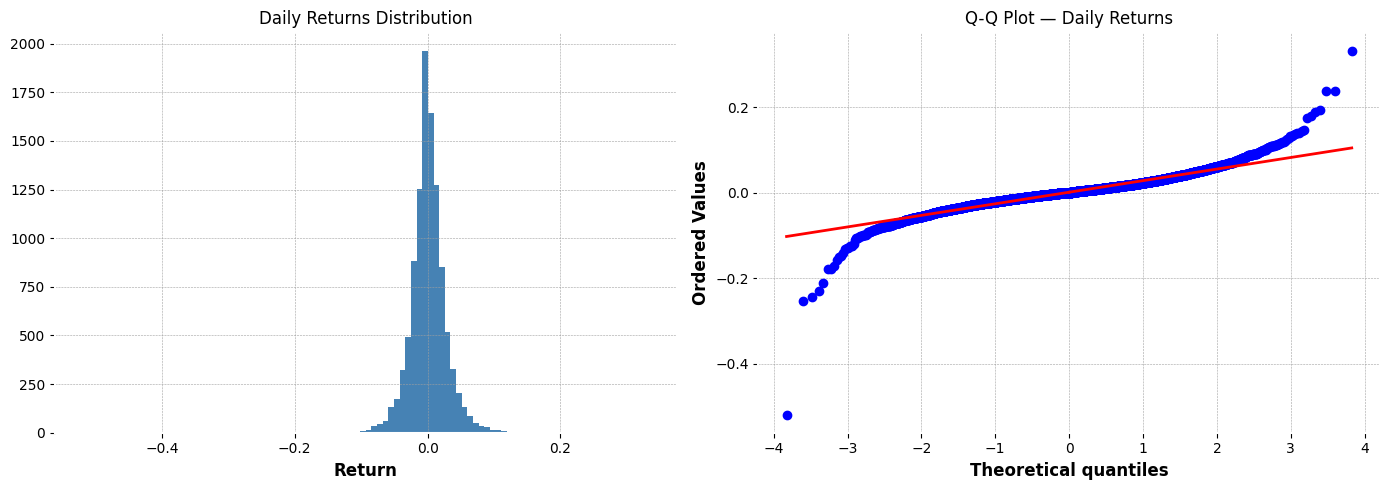

In [14]:
# Calculate daily returns
aapl_df["Daily_Return"] = aapl_df["Close"].pct_change()

# Drop NaN
returns = aapl_df["Daily_Return"].dropna()

# Shapiro-Wilk test (on sample — Shapiro needs < 5000 rows)
sample = returns.sample(1000, random_state=42)
stat, p_value = stats.shapiro(sample)

print(" NORMALITY TEST (Shapiro-Wilk) ")
print(f"Statistic : {stat:.4f}")
print(f"P-value   : {p_value:.6f}")

if p_value < 0.05:
    print("→ Not normally distributed (p < 0.05)")
else:
    print("→ Normally distributed (p >= 0.05)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

returns.hist(ax=axes[0], bins=100, color="steelblue")
axes[0].set_title("Daily Returns Distribution")
axes[0].set_xlabel("Return")

stats.probplot(returns, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot — Daily Returns")

plt.tight_layout()
plt.show()

**Étape 8 — Bien : Corrélation et conventolution**

Convolve MA shape : (10559,)

Correlation MA_50 vs Volume :
[[ 1.    -0.216]
 [-0.216  1.   ]]


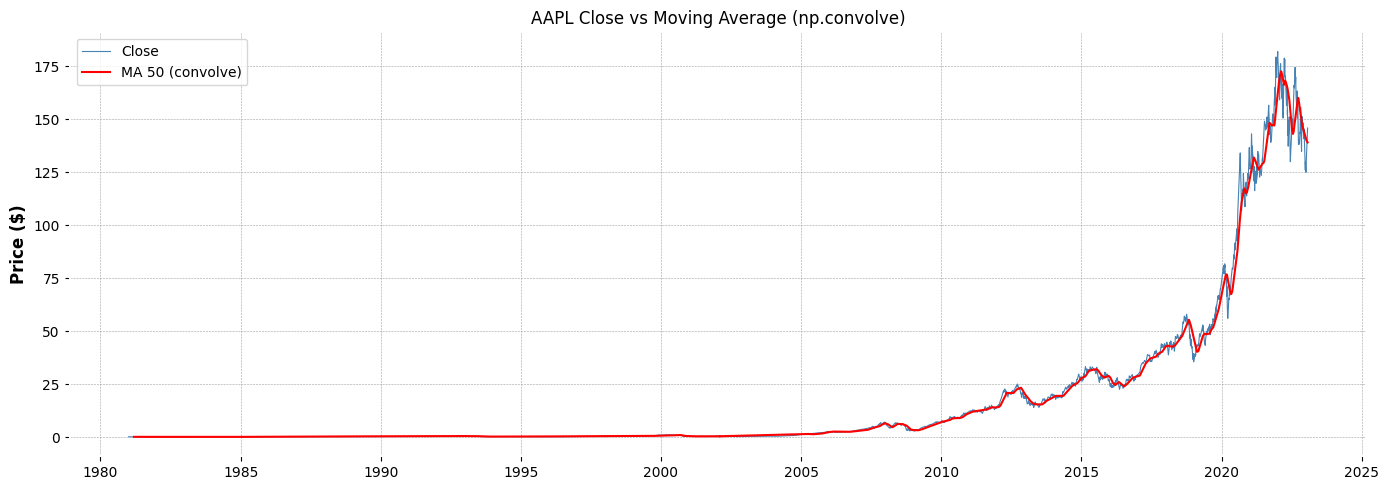

In [15]:
# 1. Moving average using np.convolve
window = 50
weights = np.ones(window) / window
ma_convolve = np.convolve(aapl_df["Close"], weights, mode="valid")

print(f"Convolve MA shape : {ma_convolve.shape}")

# 2. Correlation between MA_50 and Volume
corr = np.corrcoef(
    aapl_df["MA_50"].dropna(),
    aapl_df["Volume"].iloc[49:]
)
print(f"\nCorrelation MA_50 vs Volume :\n{corr.round(3)}")

# 3. Visualize convolve MA vs Close
plt.figure(figsize=(14, 5))
plt.plot(aapl_df["Date"], aapl_df["Close"],
         label="Close", linewidth=0.8, color="steelblue")
plt.plot(aapl_df["Date"].iloc[window-1:], ma_convolve,
         label="MA 50 (convolve)", linewidth=1.5, color="red")
plt.title("AAPL Close vs Moving Average (np.convolve)")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Cellule Markdown — Rapport complet**


## 1. Data Loading and Exploration
- Dataset : 10,608 trading days from 1981-01-02 to 2023-01-27.
- 7 columns : Date, Open, High, Low, Close, Adj Close, Volume.
- No null values found — dataset is clean.
- Date converted from DD/MM/YYYY format to datetime.

## 2. Data Visualization
- Closing prices show exponential growth from ~$0.15 (1981)
  to ~$175 (2022) — driven by iPhone launch (2007) and
  post-pandemic tech boom (2020-2021).
- Trading volume peaked around 2008-2012, then stabilized.
- Candlestick chart (last 6 months) shows high volatility
  with prices ranging between $125 and $175.

## 3. Statistical Analysis
- MA 50 and MA 200 confirm the long-term uptrend.
- MA 50 crosses above MA 200 (golden cross) multiple times,
  signaling bullish momentum.
- Both moving averages track the price closely in recent years
  due to the steep upward trend.

## 4. Hypothesis Testing

### T-Test : 2020 vs 2022 Closing Prices
| Metric | Value |
|---|---|
| Mean 2020 | $95.35 |
| Mean 2022 | $154.84 |
| T-statistic | -37.12 |
| P-value | 0.000000 |
| Conclusion | Significant difference (p < 0.05) |

Average closing price in 2022 was 62% higher than in 2020.
The difference is statistically significant.

### Normality Test : Daily Returns (Shapiro-Wilk)
| Metric | Value |
|---|---|
| Statistic | 0.9734 |
| P-value | 0.000000 |
| Conclusion | Not normally distributed (p < 0.05) |

Daily returns show a leptokurtic distribution —
sharp peak at 0 with heavy tails (extreme returns).
The Q-Q plot confirms deviation from normality
at the extremes — typical of financial data.

## 5. Advanced Statistical Techniques (Bonus)

### Moving Average with np.convolve
- np.convolve produces identical results to pandas rolling mean.
- Confirms MA 50 as a reliable trend-following indicator.

### Correlation : MA_50 vs Volume
| Pair | Correlation |
|---|---|
| MA_50 vs Volume | -0.216 |

Weak negative correlation — as price increases,
trading volume tends to slightly decrease.
High prices may reduce retail trading activity.

## 6. Summary and Insights
- AAPL stock grew from $0.15 to $175 over 42 years.
- Post-2020 growth was the most explosive in the stock's history.
- Daily returns are not normally distributed — fat tails
  indicate higher risk of extreme price movements.
- MA 50 and MA 200 are effective trend indicators for AAPL.
- Volume and price have a weak negative correlation.

## 7. Reflection
### Challenges
- Date format (DD/MM/YYYY) required explicit parsing
  with format="%d/%m/%Y".
- Shapiro-Wilk test is limited to < 5000 samples —
  a random sample of 1000 was used instead.
- Candlestick chart required installing mplfinance
  as an additional library.

### Solutions
- Used pd.to_datetime() with explicit format parameter.
- Sampled 1000 random rows for the normality test.
- Installed mplfinance via pip directly in the notebook.